In [4]:
#import necessary packages
import praw
import pandas as pd
import re
from datasets import Dataset
import numpy as np
from transformers import AutoTokenizer

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import text

import matplotlib.pyplot as plt

import tensorflow_hub as hub

In [44]:
#create reddit object
reddit = praw.Reddit(
    client_id="nL_LG3dUP5N2aE0vjROO9w",
    client_secret="ufqljcj5VGCXoTKUHPXWIcsECAGWiA",
    user_agent="aita by marvin"
)

subreddit = reddit.subreddit("AmItheAsshole")

In [45]:
def read_reddit(data):
    for post in data:
        all_posts.append([post.id,post.selftext])

In [46]:
#obtain top 1000 posts
rawdata = list()

rawdata.append(subreddit.top(limit = 1000))
rawdata.append(subreddit.search(r"*",sort = "top",time_filter = "day",limit =1000))
rawdata.append(subreddit.search(r"*",sort = "top",time_filter = "month",limit =1000))
rawdata.append(subreddit.search(r"*",sort = "top",time_filter = "year",limit =1000))
rawdata.append(subreddit.search("girlfriend",sort = "top",time_filter = "all",limit =1000))
rawdata.append(subreddit.search("boyfriend",sort = "top",time_filter = "all",limit =1000))
rawdata.append(subreddit.search("partner",sort = "top",time_filter = "all",limit =1000))
rawdata.append(subreddit.search("husband",sort = "top",time_filter = "all",limit =1000))
rawdata.append(subreddit.search("wife",sort = "top",time_filter = "all",limit =1000))
rawdata.append(subreddit.search("coworker",sort = "top",time_filter = "all",limit =1000))
rawdata.append(subreddit.search("mom",sort = "top",time_filter = "all",limit =1000))
rawdata.append(subreddit.search("dad",sort = "top",time_filter = "all",limit =1000))
rawdata.append(subreddit.search("stranger",sort = "top",time_filter = "all",limit =1000))
rawdata.append(subreddit.search("friend",sort = "top",time_filter = "all",limit =1000))
rawdata.append(subreddit.search("dog",sort = "top",time_filter = "all",limit =1000))
rawdata.append(subreddit.search("cat",sort = "top",time_filter = "all",limit =1000))
rawdata.append(subreddit.search("family",sort = "top",time_filter = "all",limit =1000))
rawdata.append(subreddit.search("son",sort = "top",time_filter = "all",limit =1000))
rawdata.append(subreddit.search("daughter",sort = "top",time_filter = "all",limit =1000))
rawdata.append(subreddit.search("brother",sort = "top",time_filter = "all",limit =1000))
rawdata.append(subreddit.search("sister",sort = "top",time_filter = "all",limit =1000))
rawdata.append(subreddit.search("kids",sort = "top",time_filter = "all",limit =1000))
rawdata.append(subreddit.search("stepdad",sort = "top",time_filter = "all",limit =1000))
rawdata.append(subreddit.search("stepmom",sort = "top",time_filter = "all",limit =1000))
rawdata.append(subreddit.search("law",sort = "top",time_filter = "all",limit =1000))
rawdata.append(subreddit.hot(limit =1000))
rawdata.append(subreddit.search(r"*",sort = "top",time_filter = "day",limit =1000))
rawdata.append(subreddit.rising())
rawdata.append(subreddit.random_rising())
rawdata.append(subreddit.controversial(time_filter="day",limit =1000))
rawdata.append(subreddit.controversial(time_filter="month",limit =1000))
rawdata.append(subreddit.controversial(time_filter="all",limit =1000))
rawdata.append(subreddit.new())

In [47]:
#store posts and ids in list
all_posts = list()
for query in rawdata:
    read_reddit(query)

In [ ]:
#remove duplicates from list and check length
tupled_lst = set(map(tuple, all_posts))
r = list(map(list, tupled_lst))
len(r)

In [49]:
#create labels based on comment consensus
new_list = list()
for i in range(0,len(r)):
    post = reddit.submission(r[i][0])
    YTA = 0
    NTA = 0
    if len(post.comments) <= 15:
            continue
    for comment in post.comments:
        j = 0
        if type(comment) == praw.models.reddit.comment.Comment:
            if re.search("YTA", comment.body, re.IGNORECASE) is not None:
                YTA = YTA + 1
            elif re.search("NTA", comment.body, re.IGNORECASE) is not None:
                NTA = NTA + 1
        j = j + 1
        if j > 100:
            break
    if YTA + NTA ==0:
        continue
    if YTA/(NTA+YTA) >= 0.7:
        r[i].append("YTA")
        new_list.append(r[i])
    elif NTA/(NTA+YTA) >= 0.7:
        r[i].append("NTA")
        new_list.append(r[i])

In [52]:
#download as csv because above takes way too long
#df = pd.DataFrame(new_list, columns=['ID','Text','Label'])
#df.to_csv("RedditAITAData.csv")

In [5]:
#read in data
rawdata = pd.read_csv("RedditAITAData.csv")
data = rawdata[["Text","Label"]]
data

In [13]:
#change from string label to 1,0
data.loc[:,('Label')] = pd.factorize(data["Label"], sort=True)[0]

In [14]:
#tokenizer = AutoTokenizer.from_pretrained("openai-gpt")
#def preprocess_function(examples):
    #return tokenizer(examples["Text"], add_special_tokens=True, truncation= True)
#df = Dataset.from_pandas(data)
#tokenized_text = df.map(preprocess_function, batched=True)

In [15]:
#Huggingface tokenizer
#from transformers import DataCollatorWithPadding
#data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="tf")

In [16]:
#label map
id2label = {0: "NTA", 1: "YTA"}
label2id = {"NTA": 0, "YTA": 1}

In [17]:
# Google baseoptions text encoder through tensorflow
model_path = 'universal_sentence_encoder.tflite'
base_options = python.BaseOptions(model_asset_path=model_path)

BaseOptions = mp.tasks.BaseOptions
TextEmbedder = mp.tasks.text.TextEmbedder
TextEmbedderOptions = mp.tasks.text.TextEmbedderOptions

In [18]:
# For creating a text embedder instance:
options = TextEmbedderOptions(
    base_options=BaseOptions(model_asset_path=model_path),
    quantize=True)
text_embedder = TextEmbedder.create_from_options(options)

I0000 00:00:1725352464.263362   76106 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 76.3), renderer: Apple M1
W0000 00:00:1725352464.308510  600488 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [19]:
# store text embeddings 
text_embeddings = list()
for text in data["Text"]:
    text_embeddings.append(text_embedder.embed(text))
    
text_embedding_list = [text_embeddings[i].embeddings[0].embedding for i in range(len(text_embeddings))]

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


In [20]:
text_embedding_list[0]

array([127,  64, 239, 127, 127, 127,   9, 128, 127, 213, 189, 184,  48,
       128, 127, 127,  79, 128, 217, 128, 128, 224,  95, 249,  35, 214,
        44, 185, 127, 127, 237, 181, 197, 225,  81,  24,  62,  81, 200,
       228, 234, 127, 127,  10, 202,   4, 210, 208,  42,  46, 128, 127,
       127, 155,   4,   9,  71, 127, 105, 127, 128,  33, 127,  65, 128,
       127, 188, 128, 248, 153, 246, 170, 128,  92, 110, 127, 184, 248,
       188, 165, 144,  12, 232,   1, 128, 127, 127, 127, 181,   2, 128,
       176, 213, 128, 218, 127, 103, 127, 206,  98], dtype=uint8)

In [24]:
# define df column names
column_names = ["embedding_" + str(i) for i in range(len(text_embedding_list[0]))]

# store text embeddings in dataframe
df = pd.DataFrame(text_embedding_list, columns=column_names)

# create target variable
df["AITA"] = data["Label"]
df.to_csv('AITA_embeddings_train.csv', index=False)
df.head()

,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,embedding_8,embedding_9,...,embedding_91,embedding_92,embedding_93,embedding_94,embedding_95,embedding_96,embedding_97,embedding_98,embedding_99,AITA
0,127,64,239,127,127,127,9,128,127,213,...,176,213,128,218,127,103,127,206,98,0
1,116,118,5,127,128,127,128,128,127,94,...,194,128,128,235,127,39,96,108,49,0
2,66,58,169,127,127,127,149,128,127,23,...,7,128,128,201,128,29,191,131,228,1
3,127,198,128,106,15,104,128,128,127,117,...,143,122,128,127,35,82,253,233,127,0
4,114,25,254,127,217,127,154,192,127,30,...,201,128,128,190,127,15,118,127,128,0


In [23]:
print(df.shape)

(4182, 101)


In [36]:
# split variables by predictors and target
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

print(type(X))

y= y.values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

<class 'pandas.core.frame.DataFrame'>


In [26]:
# apply PCA to predictors (i.e. embeddings)
pca = PCA(n_components=2).fit(X_train)
print(pca.explained_variance_ratio_)

[0.02840351 0.0229161 ]


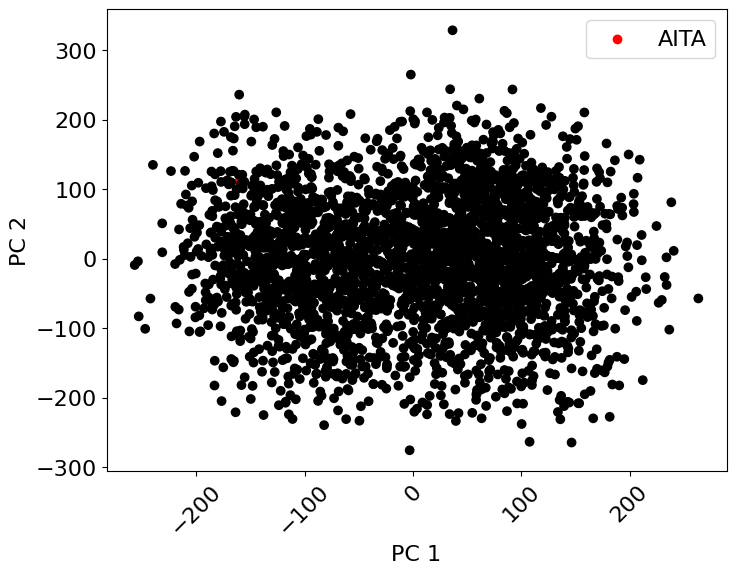

In [27]:
# plot data along PCA components
c_arr = np.array(["k"] * len(y_train))
c_arr[y_train] = "r"

plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': 16})
plt.scatter(pca.transform(X_train)[:,0], pca.transform(X_train)[:,1], c=c_arr)
plt.legend(["AITA"])
plt.xticks(rotation = 45)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()

In [28]:
# train rf model
clf = RandomForestClassifier(max_depth=2, random_state=0, n_estimators = 150).fit(X_train, y_train)
clf.score(X_train,y_train) # model accuracy for training data

0.7082336863682952

In [29]:
clf.score(X_test,y_test)

0.7019920318725099

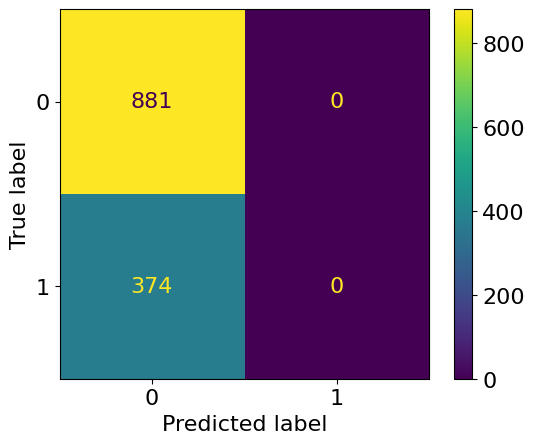

In [30]:
cm = confusion_matrix(y_test, clf.predict(X_test), labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=clf.classes_)
disp.plot()

In [77]:
test_string = "I shouted at an underpaid service worker."
text_embedder.embed(test_string).embeddings[0].embedding.astype(int)
clf.predict(text_embedder.embed(test_string).embeddings[0].embedding.astype(int).reshape(1,-1))

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([0])

In [78]:
clf = SVC(gamma = 'auto',class_weight = {0: 0.5, 1: 9}).fit(X_train, y_train)

In [79]:
clf.score(X_train,y_train)

1.0

In [80]:
clf.score(X_test,y_test)

0.7019920318725099

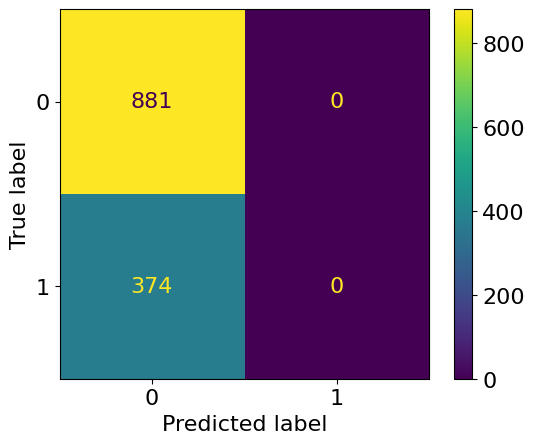

In [81]:
cm = confusion_matrix(y_test, clf.predict(X_test), labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=clf.classes_)
disp.plot()

In [82]:
test_string = "I shouted at an underpaid service worker."
text_embedder.embed(test_string).embeddings[0].embedding.astype(int)
clf.predict(text_embedder.embed(test_string).embeddings[0].embedding.astype(int).reshape(1,-1))

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([0])

In [31]:
# split variables by predictors and target
X = data["Text"]
y = data["Label"]

y= y.values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)


print(type(X_train))
print(type(y_train))

<class 'pandas.core.series.Series'>
<class 'numpy.ndarray'>


In [32]:
pipeMNB = Pipeline([('tfidf',TfidfVectorizer()),('clf', MultinomialNB())])
pipeCNB = Pipeline([('tfidf',TfidfVectorizer()),('clf', ComplementNB())])
pipeSVC = Pipeline([('tfidf',TfidfVectorizer()),('clf', LinearSVC())])

In [33]:
pipeMNB.fit(X_train,y_train)
predictMNB = pipeMNB.predict(X_test)
print(f"MNB: {accuracy_score(y_test,predictMNB):.2f}") 
pipeCNB.fit(X_train,y_train)
predictCNB = pipeCNB.predict(X_test)
print(f"CNB: {accuracy_score(y_test,predictCNB):.2f}") 
pipeSVC.fit(X_train,y_train)
predictSVC = pipeSVC.predict(X_test)
print(f"SVC: {accuracy_score(y_test,predictSVC):.2f}") 

MNB: 0.70
CNB: 0.70
SVC: 0.75


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


In [34]:
pipeMNB = Pipeline([('clf', MultinomialNB())])
pipeCNB = Pipeline([('clf', ComplementNB())])
pipeSVC = Pipeline([('clf', SVC())])

In [37]:
pipeMNB.fit(X_train,y_train)
predictMNB = pipeMNB.predict(X_test)
print(f"MNB: {accuracy_score(y_test,predictMNB):.2f}") 
pipeCNB.fit(X_train,y_train)
predictCNB = pipeCNB.predict(X_test)
print(f"CNB: {accuracy_score(y_test,predictCNB):.2f}") 
pipeSVC.fit(X_train,y_train)
predictSVC = pipeSVC.predict(X_test)
print(f"SVC: {accuracy_score(y_test,predictSVC):.2f}") 

MNB: 0.56
CNB: 0.56
SVC: 0.70


In [2]:
print(type(X_train))
print(type(y_train))

NameError: name 'X_train' is not defined

In [222]:
p = np.array([[-1, -1], [-2, -1], [1, 1], [2, 1]])

In [223]:
p

array([[-1, -1],
       [-2, -1],
       [ 1,  1],
       [ 2,  1]])

In [11]:
bert_preprocess = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3")
bert_encoder = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/4")

RuntimeError: Op type not registered 'CaseFoldUTF8' in binary running on Marvins-MacBook-Pro-5.local. Make sure the Op and Kernel are registered in the binary running in this process. Note that if you are loading a saved graph which used ops from tf.contrib (e.g. `tf.contrib.resampler`), accessing should be done before importing the graph, as contrib ops are lazily registered when the module is first accessed.